In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
path = kagglehub.dataset_download("mohamedmustafa/real-life-violence-situations-dataset")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'real-life-violence-situations-dataset' dataset.
Dataset downloaded to: /kaggle/input/real-life-violence-situations-dataset


In [ ]:
import os
for root, dirs, files in os.walk(path):
    print(root, len(files), "files")
    if len(files) > 0:
        break

/kaggle/input/real-life-violence-situations-dataset 0 files
/kaggle/input/real-life-violence-situations-dataset/real life violence situations 0 files
/kaggle/input/real-life-violence-situations-dataset/real life violence situations/Real Life Violence Dataset 0 files
/kaggle/input/real-life-violence-situations-dataset/real life violence situations/Real Life Violence Dataset/NonViolence 1000 files


In [ ]:
SRC = "/kaggle/input/real-life-violence-situations-dataset/real life violence situations/Real Life Violence Dataset"

import os
print(os.listdir(SRC))

['NonViolence', 'Violence']


In [ ]:
import cv2, glob, random

OUT = "/content/frames"
for split in ["train", "val"]:
    for cls in ["Violence", "NonViolence"]:
        os.makedirs(f"{OUT}/{split}/{cls}", exist_ok=True)

def extract(video_path, out_dir, every_n=15):
    cap = cv2.VideoCapture(video_path)
    count, saved = 0, 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if count % every_n == 0:
            cv2.imwrite(f"{out_dir}/{os.path.basename(video_path)}_{saved}.jpg", cv2.resize(frame, (224,224)))
            saved += 1
        count += 1
    cap.release()

for cls in ["Violence", "NonViolence"]:
    videos = glob.glob(f"{SRC}/{cls}/*.mp4")
    print(cls, "videos found:", len(videos))
    random.shuffle(videos)
    split_point = int(len(videos)*0.85)
    for v in videos[:split_point]:
        extract(v, f"{OUT}/train/{cls}")
    for v in videos[split_point:]:
        extract(v, f"{OUT}/val/{cls}")

print("Train violence frames:", len(os.listdir(f"{OUT}/train/Violence")))
print("Train nonviolence frames:", len(os.listdir(f"{OUT}/train/NonViolence")))

Violence videos found: 1000
NonViolence videos found: 951
Train violence frames: 9568
Train nonviolence frames: 7217


In [ ]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/frames/train", image_size=(224,224), batch_size=32, label_mode='binary')
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/frames/val", image_size=(224,224), batch_size=32, label_mode='binary')

print(train_ds.class_names)  # confirm which index is which class

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
base = tf.keras.applications.MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = preprocess(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Found 16785 files belonging to 2 classes.
Found 2742 files belonging to 2 classes.
['NonViolence', 'Violence']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 67s 88ms/step - accuracy: 0.7377 - loss: 0.5306 - val_accuracy: 0.8202 - val_loss: 0.4031
Epoch 2/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.8425 - loss: 0.3655 - val_accuracy: 0.8538 - val_loss: 0.3372
Epoch 3/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.8712 - loss: 0.3096 - val_accuracy: 0.8654 - val_loss: 0.3095
Epoch 4/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8884 - loss: 0.2802 - val_accuracy: 0.8760 - val_loss: 0.2930
Epoch 5/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.8919 - loss: 0.2616 - val_accuracy: 0.8807 - val_loss: 0.2836
Epoch 6/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.9021 - loss: 0.2438 - val_accuracy: 0.8844 - val_loss: 0.2762
Epoch 7/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.9056 - loss: 0.2351 - val_accuracy: 0.8873 - val_loss: 0.2686
Epoch 8/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.9077 - loss: 0.2287 - 

In [ ]:
model.save('/content/violence_model.h5')
from google.colab import files
files.download('/content/violence_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save('/content/violence_model.keras')
from google.colab import files
files.download('/content/violence_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
from collections import deque

# Load your trained model
model = tf.keras.models.load_model('/content/violence_model.keras')

def predict_video(video_path, window_size=15, threshold=0.7, sample_every=5):
    cap = cv2.VideoCapture(video_path)
    window = deque(maxlen=window_size)
    frame_count = 0
    alerts = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % sample_every == 0:
            img = cv2.resize(frame, (224, 224))
            img = np.expand_dims(img, axis=0).astype(np.float32)
            pred = model.predict(img, verbose=0)[0][0]  # 0=NonViolence, 1=Violence
            window.append(pred)

            smoothed_conf = sum(window) / len(window)

            if smoothed_conf > threshold:
                timestamp_sec = frame_count / cap.get(cv2.CAP_PROP_FPS)
                alerts.append({
                    "hazard_type": "violence",
                    "confidence": round(float(smoothed_conf), 2),
                    "severity": "High" if smoothed_conf > 0.85 else "Medium",
                    "camera_id": "CAM-02",   # placeholder, wire to real camera ID later
                    "timestamp": round(timestamp_sec, 1)
                })

        frame_count += 1

    cap.release()
    return alerts

# Test it
results = predict_video("/content/sample_test_video.mp4")
for r in results:
    print(r)

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
results = predict_video("/content/sample_test_video.mp4")
for r in results:
    print(r)

In [ ]:
import glob

test_videos = glob.glob(f"{SRC}/Violence/*.mp4")
test_video = test_videos[0]
print("Testing on:", test_video)

results = predict_video(test_video)
for r in results:
    print(r)

Testing on: /kaggle/input/real-life-violence-situations-dataset/real life violence situations/Real Life Violence Dataset/Violence/V_465.mp4
{'hazard_type': 'violence', 'confidence': 0.79, 'severity': 'Medium', 'camera_id': 'CAM-02', 'timestamp': 0.0}
{'hazard_type': 'violence', 'confidence': 0.81, 'severity': 'Medium', 'camera_id': 'CAM-02', 'timestamp': 0.2}
{'hazard_type': 'violence', 'confidence': 0.87, 'severity': 'High', 'camera_id': 'CAM-02', 'timestamp': 0.3}
{'hazard_type': 'violence', 'confidence': 0.9, 'severity': 'High', 'camera_id': 'CAM-02', 'timestamp': 0.5}
{'hazard_type': 'violence', 'confidence': 0.92, 'severity': 'High', 'camera_id': 'CAM-02', 'timestamp': 0.7}
{'hazard_type': 'violence', 'confidence': 0.93, 'severity': 'High', 'camera_id': 'CAM-02', 'timestamp': 0.8}
{'hazard_type': 'violence', 'confidence': 0.94, 'severity': 'High', 'camera_id': 'CAM-02', 'timestamp': 1.0}
{'hazard_type': 'violence', 'confidence': 0.95, 'severity': 'High', 'camera_id': 'CAM-02', 'ti

In [ ]:
test_videos_nv = glob.glob(f"{SRC}/NonViolence/*.mp4")
test_nv = test_videos_nv[0]
print("Testing on:", test_nv)

results_nv = predict_video(test_nv)
if results_nv:
    print(f"⚠️ {len(results_nv)} false alerts triggered")
    for r in results_nv:
        print(r)
else:
    print("✅ No false alerts — correctly identified as non-violent")

Testing on: /kaggle/input/real-life-violence-situations-dataset/real life violence situations/Real Life Violence Dataset/NonViolence/NV_759.mp4
✅ No false alerts — correctly identified as non-violent


In [ ]:
def consolidate_alerts(alerts, gap_threshold=2.0):
    if not alerts:
        return []

    incidents = []
    current = {
        "hazard_type": "violence",
        "camera_id": alerts[0]["camera_id"],
        "start_time": alerts[0]["timestamp"],
        "end_time": alerts[0]["timestamp"],
        "max_confidence": alerts[0]["confidence"],
        "severity": alerts[0]["severity"]
    }

    for a in alerts[1:]:
        if a["timestamp"] - current["end_time"] <= gap_threshold:
            current["end_time"] = a["timestamp"]
            current["max_confidence"] = max(current["max_confidence"], a["confidence"])
            if a["severity"] == "High":
                current["severity"] = "High"
        else:
            incidents.append(current)
            current = {
                "hazard_type": "violence",
                "camera_id": a["camera_id"],
                "start_time": a["timestamp"],
                "end_time": a["timestamp"],
                "max_confidence": a["confidence"],
                "severity": a["severity"]
            }
    incidents.append(current)
    return incidents

incidents = consolidate_alerts(results)
for i in incidents:
    print(i)

{'hazard_type': 'violence', 'camera_id': 'CAM-02', 'start_time': 0.0, 'end_time': 4.7, 'max_confidence': 0.98, 'severity': 'High'}


In [ ]:
test_videos_nv = glob.glob(f"{SRC}/NonViolence/*.mp4")

for test_nv in test_videos_nv[:5]:
    print("Testing on:", test_nv)
    results_nv = predict_video(test_nv)
    if results_nv:
        print(f"⚠️ {len(results_nv)} false alerts triggered")
    else:
        print("✅ No false alerts")
    print()

Testing on: /kaggle/input/real-life-violence-situations-dataset/real life violence situations/Real Life Violence Dataset/NonViolence/NV_759.mp4
✅ No false alerts

Testing on: /kaggle/input/real-life-violence-situations-dataset/real life violence situations/Real Life Violence Dataset/NonViolence/NV_564.mp4
✅ No false alerts

Testing on: /kaggle/input/real-life-violence-situations-dataset/real life violence situations/Real Life Violence Dataset/NonViolence/NV_126.mp4
✅ No false alerts

Testing on: /kaggle/input/real-life-violence-situations-dataset/real life violence situations/Real Life Violence Dataset/NonViolence/NV_601.mp4
⚠️ 13 false alerts triggered

Testing on: /kaggle/input/real-life-violence-situations-dataset/real life violence situations/Real Life Violence Dataset/NonViolence/NV_397.mp4
✅ No false alerts



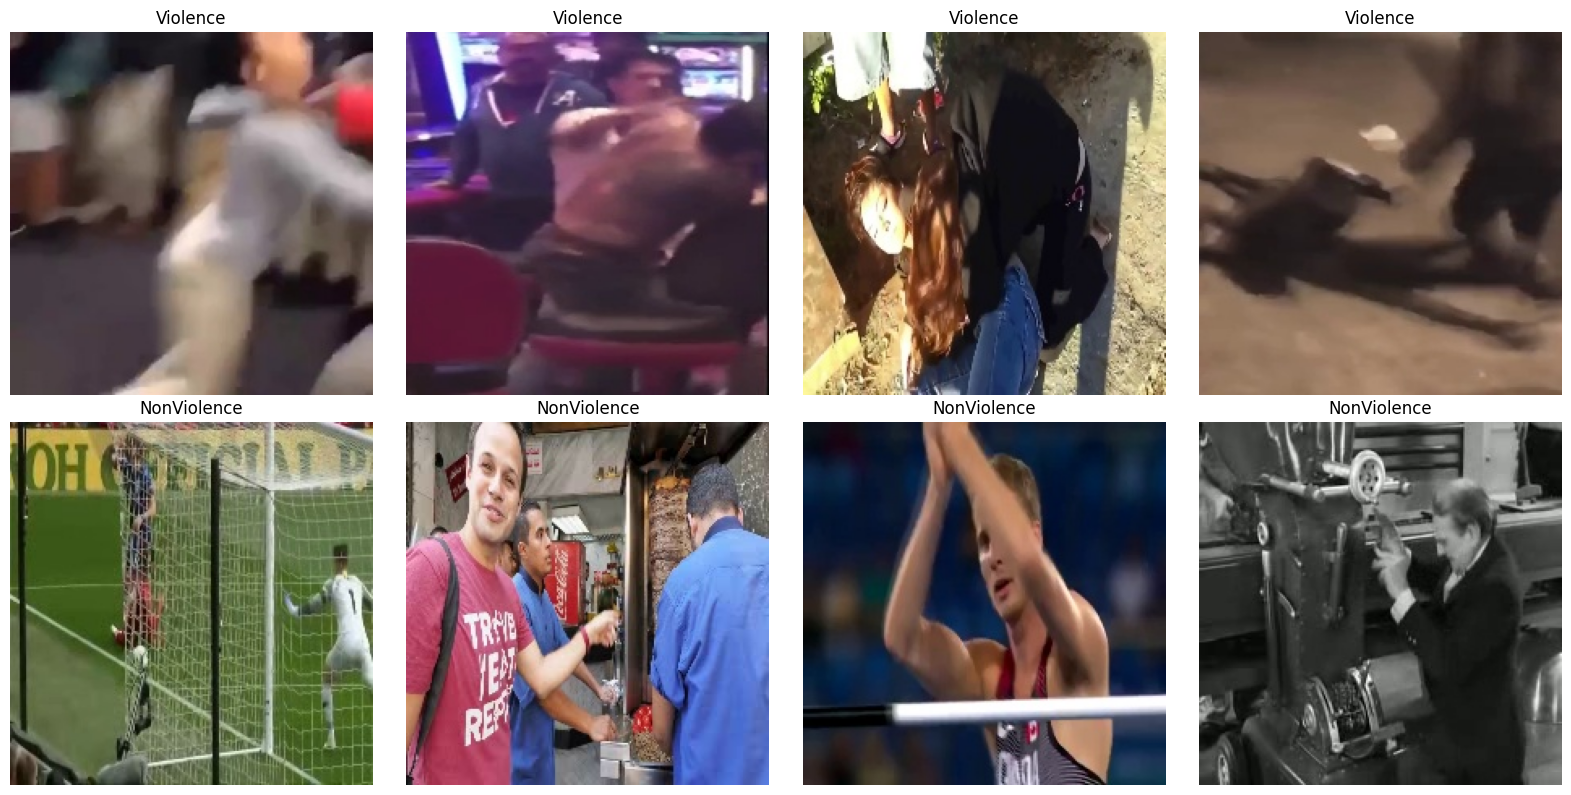

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import os, random

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, cls in enumerate(["Violence", "NonViolence"]):
    frame_dir = f"/content/frames/train/{cls}"
    samples = random.sample(os.listdir(frame_dir), 4)
    for j, fname in enumerate(samples):
        img = plt.imread(f"{frame_dir}/{fname}")
        axes[i][j].imshow(img)
        axes[i][j].set_title(cls)
        axes[i][j].axis('off')

plt.tight_layout()
plt.savefig('/content/sample_frames.png', dpi=150)
plt.show()

from google.colab import files
files.download('/content/sample_frames.png')

In [ ]:
pip install fastapi uvicorn tensorflow opencv-python python-multipart


In [ ]:
from fastapi import FastAPI, UploadFile, File
import tensorflow as tf
import numpy as np
import cv2
from collections import deque
import tempfile, os

app = FastAPI()
model = tf.keras.models.load_model('violence_model.keras')

def predict_video(video_path, window_size=15, threshold=0.8, sample_every=5):
    cap = cv2.VideoCapture(video_path)
    window = deque(maxlen=window_size)
    frame_count = 0
    alerts = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % sample_every == 0:
            img = cv2.resize(frame, (224, 224))
            img = np.expand_dims(img, axis=0).astype(np.float32)
            pred = model.predict(img, verbose=0)[0][0]
            window.append(pred)
            smoothed_conf = sum(window) / len(window)
            if smoothed_conf > threshold:
                timestamp_sec = frame_count / cap.get(cv2.CAP_PROP_FPS)
                alerts.append({
                    "hazard_type": "violence",
                    "confidence": round(float(smoothed_conf), 2),
                    "severity": "High" if smoothed_conf > 0.85 else "Medium",
                    "camera_id": "CAM-02",
                    "timestamp": round(timestamp_sec, 1)
                })
        frame_count += 1
    cap.release()
    return alerts

def consolidate_alerts(alerts, gap_threshold=2.0):
    if not alerts:
        return []
    incidents = []
    current = dict(alerts[0], start_time=alerts[0]["timestamp"], end_time=alerts[0]["timestamp"], max_confidence=alerts[0]["confidence"])
    for a in alerts[1:]:
        if a["timestamp"] - current["end_time"] <= gap_threshold:
            current["end_time"] = a["timestamp"]
            current["max_confidence"] = max(current["max_confidence"], a["confidence"])
            if a["severity"] == "High":
                current["severity"] = "High"
        else:
            incidents.append(current)
            current = dict(a, start_time=a["timestamp"], end_time=a["timestamp"], max_confidence=a["confidence"])
    incidents.append(current)
    return incidents

@app.post("/detect/violence")
async def detect_violence(file: UploadFile = File(...)):
    with tempfile.NamedTemporaryFile(delete=False, suffix=".mp4") as tmp:
        tmp.write(await file.read())
        tmp_path = tmp.name

    raw_alerts = predict_video(tmp_path)
    incidents = consolidate_alerts(raw_alerts)
    os.remove(tmp_path)

    return {"incidents": incidents}

In [ ]:
uvicorn violence_service:app --reload --port 8001

SyntaxError: invalid syntax (2202475605.py, line 1)

In [ ]:
!uvicorn violence_service:app --reload --port 8001

INFO:     Will watch for changes in these directories: ['/content']
INFO:     Uvicorn running on http://127.0.0.1:8001 (Press CTRL+C to quit)
INFO:     Started reloader process [22656] using WatchFiles
ERROR:    Error loading ASGI app. Could not import module "violence_service".
INFO:     Stopping reloader process [22656]


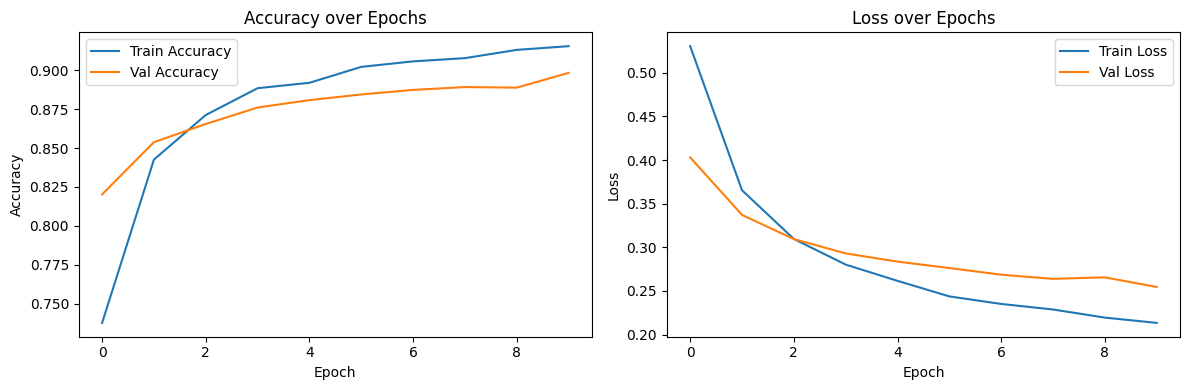

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

from google.colab import files
files.download('/content/training_curves.png')


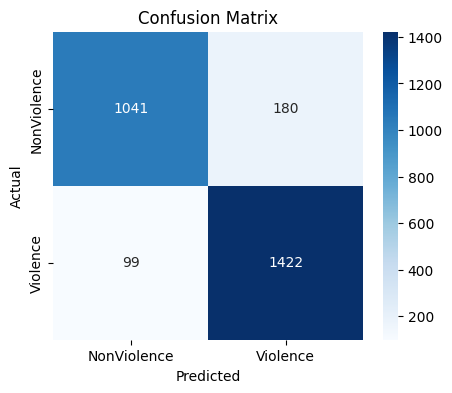

              precision    recall  f1-score   support

 NonViolence       0.91      0.85      0.88      1221
    Violence       0.89      0.93      0.91      1521

    accuracy                           0.90      2742
   macro avg       0.90      0.89      0.90      2742
weighted avg       0.90      0.90      0.90      2742



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend((preds.flatten() > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NonViolence','Violence'],
            yticklabels=['NonViolence','Violence'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=['NonViolence','Violence']))

files.download('/content/confusion_matrix.png')

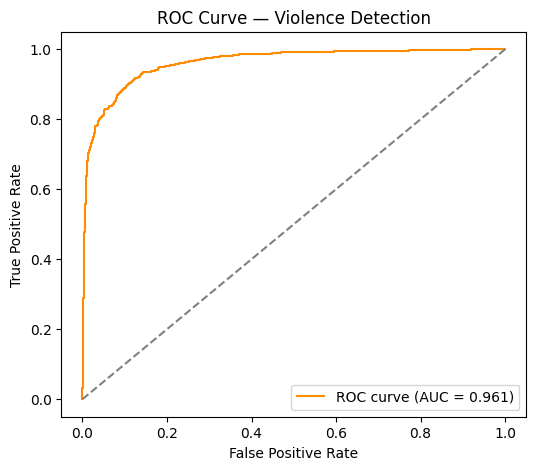

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import roc_curve, auc

y_scores = []
y_true = []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_scores.extend(preds.flatten())
    y_true.extend(labels.numpy().flatten())

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', color='darkorange')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Violence Detection')
plt.legend()
plt.savefig('/content/roc_curve.png', dpi=150)
plt.show()
files.download('/content/roc_curve.png')

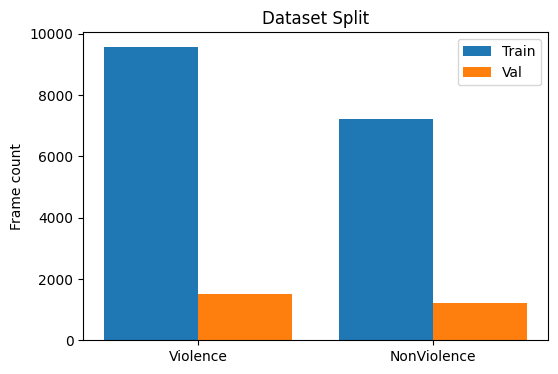

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

train_counts = {cls: len(os.listdir(f"/content/frames/train/{cls}")) for cls in ["Violence","NonViolence"]}
val_counts = {cls: len(os.listdir(f"/content/frames/val/{cls}")) for cls in ["Violence","NonViolence"]}

fig, ax = plt.subplots(figsize=(6,4))
x = range(2)
ax.bar([i-0.2 for i in x], train_counts.values(), width=0.4, label='Train')
ax.bar([i+0.2 for i in x], val_counts.values(), width=0.4, label='Val')
ax.set_xticks(list(x)); ax.set_xticklabels(train_counts.keys())
ax.set_ylabel('Frame count'); ax.set_title('Dataset Split')
ax.legend()
plt.savefig('/content/dataset_distribution.png', dpi=150)
plt.show()
files.download('/content/dataset_distribution.png')

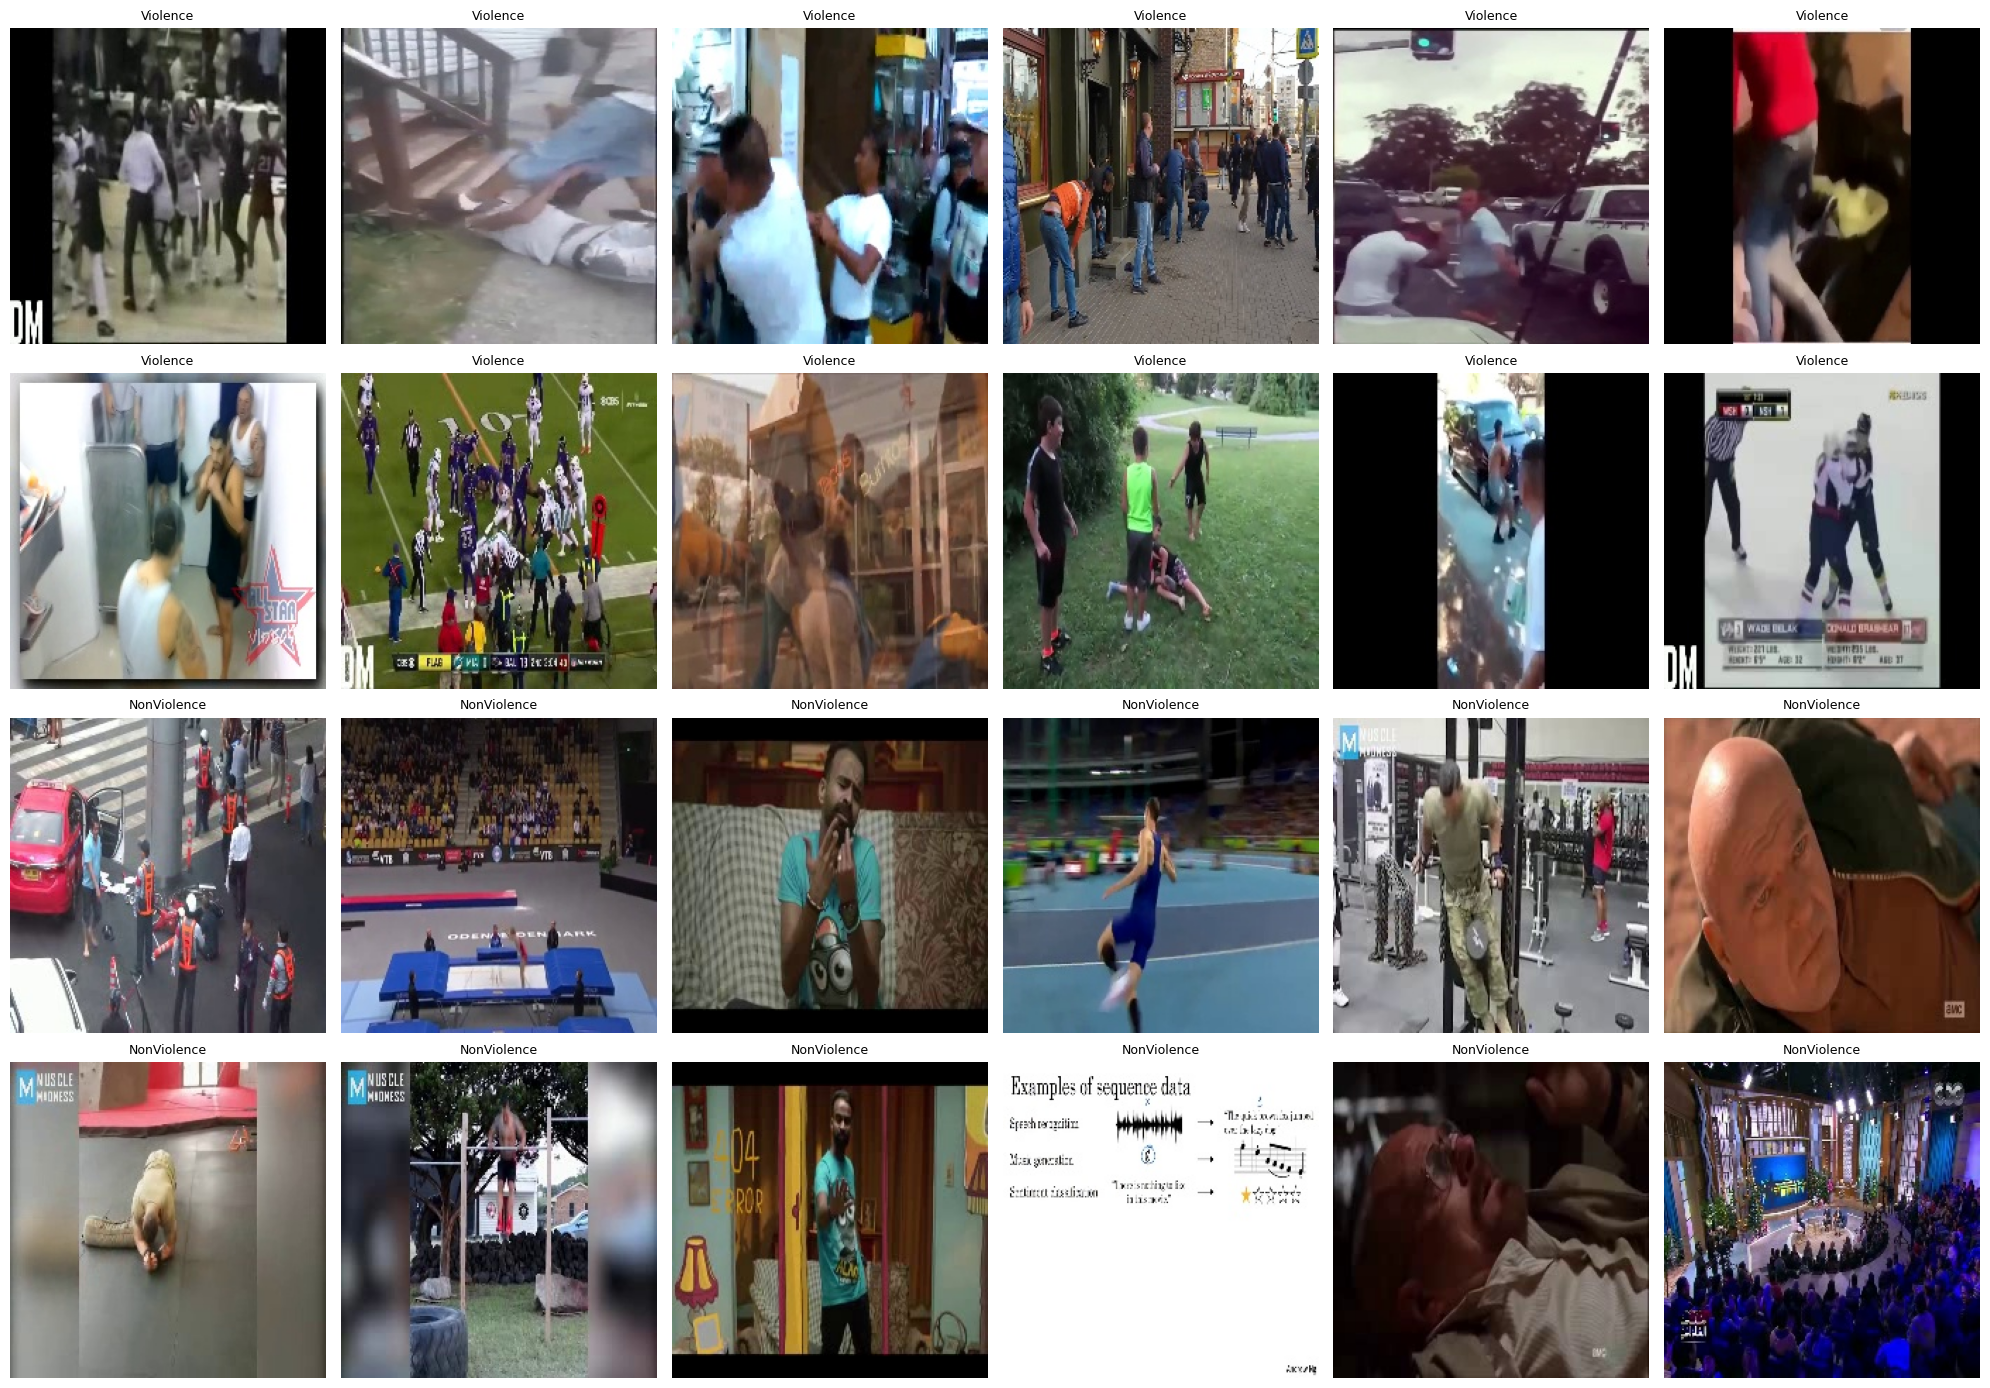

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import os, random

fig, axes = plt.subplots(4, 6, figsize=(20, 14))

for i, cls in enumerate(["Violence", "NonViolence"]):
    frame_dir = f"/content/frames/train/{cls}"
    samples = random.sample(os.listdir(frame_dir), 12)
    for j, fname in enumerate(samples):
        row = i * 2 + j // 6
        col = j % 6
        img = plt.imread(f"{frame_dir}/{fname}")
        axes[row][col].imshow(img)
        axes[row][col].set_title(cls, fontsize=9)
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('/content/sample_frames_large.png', dpi=150)
plt.show()

from google.colab import files
files.download('/content/sample_frames_large.png')